# CMM synthetic validation

CMM uses flexmix (mixture of linear regressions), which assumes Gaussian conditional distributions.
Real TB data has binary mutation columns, handled via a Gaussian noise workaround.

This notebook tests whether CMM reliably recovers causal edges under two conditions:
- **binary → continuous** (mutation → MIC): the edge type we care about most
- **binary → binary** (mutation → mutation): the edge type dominating the real bootstrap results

Mixture structure: latent Z creates two subpopulations with different causal mechanisms.

In [3]:
import sys
sys.path.insert(0, '..')
sys.path.insert(0, '../external/cmm')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from src_tb.data.synthetic import SyntheticData
from src_tb.causal_recovery.evaluation import eval_recovery
from src_tb.causal_recovery.cmm_utils import run_cmm, bootstrap_cmm, get_stable_edges, build_stable_bn
import pyagrum.lib.notebook as gnb

N_MUTATIONS = 8 #will be rounded down to the nearest multiple of 4, minimum 4
N_SEEDS = 5
N_BOOTSTRAP = 10
THRESHOLD = 0.5

Direct:   {('mut_0', 'Y'), ('mut_1', 'Y')}
Bin->bin: {('mut_2', 'mut_4'), ('mut_3', 'mut_5')}
Chain:    {('mut_5', 'Y'), ('mut_4', 'Y')}


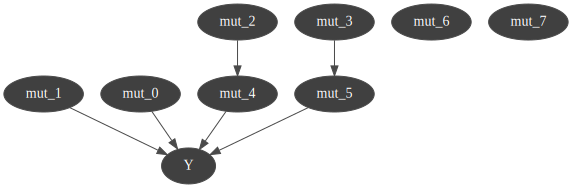

In [ ]:
#show the true DAG for the chosen n_mutations
data = SyntheticData(N_MUTATIONS)
print(f"Direct:   {data.true_direct}")
print(f"Bin->bin: {data.true_bin_to_bin}")
print(f"Chain:    {data.true_chain_cont}")
data.visualize_true_dag()

## Raw CMM

In [5]:
records = []
for seed in range(N_SEEDS):
    X, features_synth, true_edges, binary_indices_synth = generate_synthetic(N_MUTATIONS, seed=seed)
    cmm_list = bootstrap_cmm(X, set(), binary_indices_synth, n_runs=N_BOOTSTRAP)
    stable = get_stable_edges(cmm_list, features_synth, threshold=THRESHOLD)
    stable_set = set(zip(stable['source'], stable['target']))

    pr_d,  re_d,  f1_d  = eval_recovery(stable_set, true_direct)
    pr_bb, re_bb, f1_bb = eval_recovery(stable_set, true_bin_to_bin)
    pr_cc, re_cc, f1_cc = eval_recovery(stable_set, true_chain_cont)
    records.append({
        'seed': seed, 'stable_edges': stable_set,
        'direct P': pr_d,   'direct R': re_d,   'direct F1': f1_d,
        'bin->bin P': pr_bb, 'bin->bin R': re_bb, 'bin->bin F1': f1_bb,
        'chain P': pr_cc,   'chain R': re_cc,   'chain F1': f1_cc,
    })
    print(f"seed {seed} | {stable_set}")
    print(f"  direct    P={pr_d}  R={re_d}  F1={f1_d}")
    print(f"  bin->bin  P={pr_bb} R={re_bb} F1={f1_bb}")
    print(f"  chain     P={pr_cc} R={re_cc} F1={f1_cc}")

df = pd.DataFrame(records)

seed 0 | {('mut_4', 'Y'), ('mut_5', 'Y'), ('mut_0', 'Y'), ('mut_1', 'Y')}
  direct    P=0.5  R=1.0  F1=0.667
  bin->bin  P=0.0 R=0.0 F1=0.0
  chain     P=0.5 R=1.0 F1=0.667
seed 1 | {('mut_4', 'Y'), ('mut_5', 'Y'), ('mut_0', 'Y'), ('mut_2', 'Y')}
  direct    P=0.25  R=0.5  F1=0.333
  bin->bin  P=0.0 R=0.0 F1=0.0
  chain     P=0.5 R=1.0 F1=0.667
seed 2 | {('mut_5', 'Y'), ('mut_0', 'Y'), ('mut_6', 'Y'), ('mut_1', 'Y')}
  direct    P=0.5  R=1.0  F1=0.667
  bin->bin  P=0.0 R=0.0 F1=0.0
  chain     P=0.25 R=0.5 F1=0.333
seed 3 | {('mut_0', 'Y'), ('mut_1', 'Y')}
  direct    P=1.0  R=1.0  F1=1.0
  bin->bin  P=0.0 R=0.0 F1=0.0
  chain     P=0.0 R=0.0 F1=0.0
seed 4 | {('mut_3', 'mut_5'), ('mut_3', 'Y'), ('mut_5', 'Y'), ('mut_0', 'Y'), ('mut_4', 'Y'), ('mut_1', 'Y')}
  direct    P=0.333  R=1.0  F1=0.5
  bin->bin  P=0.167 R=0.5 F1=0.25
  chain     P=0.333 R=1.0 F1=0.5


In [10]:
cols = ['direct P', 'direct R', 'direct F1',
        'bin->bin P', 'bin->bin R', 'bin->bin F1',
        'chain P', 'chain R', 'chain F1']
print("Mean across seeds")
print(df[cols].mean().round(3).to_string())

Mean across seeds
direct P       0.517
direct R       0.900
direct F1      0.633
bin->bin P     0.033
bin->bin R     0.100
bin->bin F1    0.050
chain P        0.317
chain R        0.700
chain F1       0.433


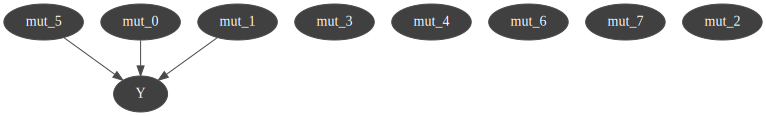

In [9]:
X_last, features_synth, true_edges, binary_indices_synth = generate_synthetic(N_MUTATIONS, seed=N_SEEDS - 1)
cmm_list_last = bootstrap_cmm(X_last, set(), binary_indices_synth, n_runs=N_BOOTSTRAP)
bn = build_stable_bn(cmm_list_last, features_synth, threshold=THRESHOLD)
gnb.showBN(bn, size="20")

As expected, CMM reliably recovers direct edges, partially recovers chains, but falls short on binary -> binary edges.

## CMM with fix

In [4]:
data = SyntheticData(4, seed=0)
cmm = run_cmm(data.X, set())
recovered = {(data.features[i], data.features[j]) for i, j in cmm.dag.edges()}
print(f"Recovered: {recovered}")
print(f"True:      {data.true_edges}")

Recovered: {('mut_2', 'Y'), ('mut_0', 'Y'), ('mut_1', 'mut_2')}
True:      {('mut_2', 'Y'), ('mut_0', 'Y'), ('mut_1', 'mut_2')}
